# 【notebook｜N-12】LoRA 从零实现与 PEFT 对照
> 对应：《05-LoRA/01-LoRA原理.md》【文档｜DOC-LORA】；代码 `F-b05-lora`、`F-b05-peft_lora`

**对应理论**：`05-LoRA/01-LoRA原理.md`

**对应 AlphaProof 源码**：
- `reap-new-update-model/app/policy_server.py:112-116`（r=16, alpha=32, dropout=0.02）
- `v1-1-agentic-tool/gpu/gpu_runtime/real_backend.py:24,117-128`（TARGET_MODULES、per-session adapter）

**Colab 运行说明**：前半段手写 LoRA 只依赖 torch（CPU 秒级）；最后一节可选
`peft`（`pip install peft`）做对照。点“全部运行”即可。

In [1]:
# 【N-12.c1】
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.12.0+git6bbd260


## 1. 公式

$$
h = W_0 x + \frac{\alpha}{r}\,B\,A\,x,\qquad B_0 = 0 \Rightarrow \Delta W = 0
$$

$B$ 零初始化保证微调从“等价基座”出发；$\alpha/r$ 是尺度归一化。

In [2]:
# 【N-12.c2】
TARGET_MODULES = ("q_proj", "k_proj", "v_proj", "o_proj",
                  "gate_proj", "up_proj", "down_proj")

class LoRALinear(nn.Module):
    def __init__(self, base, r=16, alpha=32, dropout=0.0):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)
        self.r, self.scaling = r, alpha / r
        self.drop = nn.Dropout(dropout)
        self.A = nn.Parameter(torch.empty(r, base.in_features, device=base.weight.device, dtype=base.weight.dtype))
        self.B = nn.Parameter(torch.zeros(base.out_features, r, device=base.weight.device, dtype=base.weight.dtype))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))   # B=0
    def forward(self, x):
        return self.base(x) + self.scaling * (self.drop(x) @ self.A.t() @ self.B.t())
    @torch.no_grad()
    def merge(self):
        self.base.weight.data += self.scaling * (self.B @ self.A)
        return self.base

class MHA(nn.Module):
    def __init__(self, d, nh):
        super().__init__()
        self.nh, self.hd = nh, d // nh
        self.q_proj = nn.Linear(d, d, bias=False)
        self.k_proj = nn.Linear(d, d, bias=False)
        self.v_proj = nn.Linear(d, d, bias=False)
        self.o_proj = nn.Linear(d, d, bias=False)
    def forward(self, x):
        b, t, c = x.shape
        q = self.q_proj(x).view(b, t, self.nh, self.hd).transpose(1, 2)
        k = self.k_proj(x).view(b, t, self.nh, self.hd).transpose(1, 2)
        v = self.v_proj(x).view(b, t, self.nh, self.hd).transpose(1, 2)
        o = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o_proj(o.transpose(1, 2).contiguous().view(b, t, c))

class MLP(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.gate_proj = nn.Linear(d, h, bias=False)
        self.up_proj = nn.Linear(d, h, bias=False)
        self.down_proj = nn.Linear(h, d, bias=False)
    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

class TinyGPT(nn.Module):
    def __init__(self, vocab=64, d=128, layers=4, heads=4, ctx=16):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(ctx, d)
        self.blocks = nn.ModuleList([
            nn.ModuleDict({"ln1": nn.LayerNorm(d), "attn": MHA(d, heads),
                           "ln2": nn.LayerNorm(d), "mlp": MLP(d, 4 * d)})
            for _ in range(layers)])
        self.lnf = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
    def forward(self, idx):
        b, t = idx.shape
        x = self.tok(idx) + self.pos(torch.arange(t, device=idx.device))[None]
        for blk in self.blocks:
            x = x + blk["attn"](blk["ln1"](x))
            x = x + blk["mlp"](blk["ln2"](x))
        return self.head(self.lnf(x))

def inject_lora(model, names=TARGET_MODULES, r=16, alpha=32, dropout=0.0):
    for mname, module in list(model.named_modules()):
        for cname, child in list(module.named_children()):
            full = f"{mname}.{cname}" if mname else cname
            if isinstance(child, nn.Linear) and full.split(".")[-1] in names:
                setattr(module, cname, LoRALinear(child, r, alpha, dropout))
    return model

def count(model, trainable=True):
    return sum(p.numel() for p in model.parameters() if p.requires_grad or not trainable)

print("LoRA/TinyGPT 工具已加载")

LoRA/TinyGPT 工具已加载


## 2. 注入 LoRA 并统计可训练参数

先验证注入后**初始输出与基座一致**（因为 B=0），再对比参数量。

In [3]:
# 【N-12.c3】
torch.manual_seed(1)
base = TinyGPT().to(device)
x = torch.randint(0, 64, (4, 16), device=device)
with torch.no_grad():
    before = base(x)
total = count(base, trainable=False)

lora_model = TinyGPT().to(device)
lora_model.load_state_dict(base.state_dict())
inject_lora(lora_model, r=16, alpha=32)
lora_model.to(device)
with torch.no_grad():
    after = lora_model(x)

for n_, p in lora_model.named_parameters():
    p.requires_grad_("A" in n_ or "B" in n_)
n_lora = count(lora_model, trainable=True)
print("total params        :", total)
print("lora trainable      :", n_lora, f"({100*n_lora/total:.2f}%)")
print("modules wrapped     :", sum(isinstance(m, LoRALinear) for m in lora_model.modules()))
print("init max |diff|     :", float((before - after).abs().max()), "(应≈0)")

total params        : 1069312
lora trainable      : 188416 (17.62%)
modules wrapped     : 28
init max |diff|     : 0.0 (应≈0)


## 3. 冻结 / 全参 / LoRA 三种微调对照

任务：把随机序列逆序复制。观察三种设置的 loss 是否都能下降。

frozen   first=4.275 final=4.354


/tmp/ipykernel_17654/1566942427.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /app/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  opt.step(); losses.append(float(loss))


full     first=4.275 final=2.090


lora     first=4.351 final=2.144


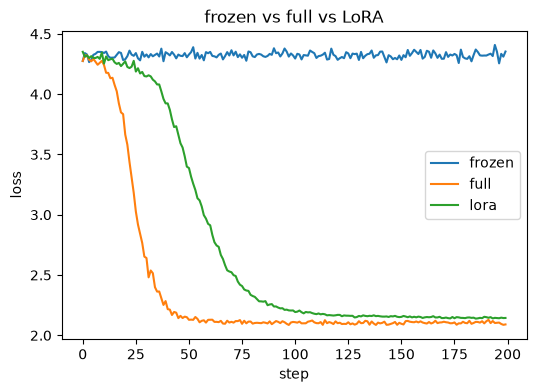

In [4]:
# 【N-12.c4】
def make_batch(bs=32, seq=16, vocab=64):
    x = torch.randint(0, vocab, (bs, seq), device=device)
    return x, torch.flip(x, dims=[1])

def train(model, params, steps=200, lr=3e-3, tag=""):
    p_list = params if params is not None else [p for p in model.parameters() if p.requires_grad]
    if not p_list: p_list = [next(model.parameters())]  # frozen 占位，避免空 optimizer
    opt = torch.optim.AdamW(p_list, lr=lr)
    losses = []
    for s in range(steps):
        xb, yb = make_batch()
        logits = model(xb)
        loss = F.cross_entropy(logits.reshape(-1, 64), yb.reshape(-1))
        opt.zero_grad(set_to_none=True)
        if loss.requires_grad: loss.backward()
        if params: torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step(); losses.append(float(loss))
    print(f"{tag:8s} first={losses[0]:.3f} final={losses[-1]:.3f}")
    return losses

# frozen
torch.manual_seed(2); m = TinyGPT().to(device)
for p in m.parameters(): p.requires_grad_(False)
dummy = torch.zeros(1, device=device, requires_grad=True)
lf = train(m, [dummy], tag="frozen")

# full
torch.manual_seed(2); m = TinyGPT().to(device)
lfull = train(m, None, tag="full")

# lora
torch.manual_seed(2); m = TinyGPT().to(device)
inject_lora(m, r=16, alpha=32)
lp = [p for n_, p in m.named_parameters() if "A" in n_ or "B" in n_]
llora = train(m, lp, tag="lora")

plt.figure(figsize=(6,4))
plt.plot(lf, label="frozen"); plt.plot(lfull, label="full"); plt.plot(llora, label="lora")
plt.xlabel("step"); plt.ylabel("loss"); plt.title("frozen vs full vs LoRA"); plt.legend(); plt.show()

## 4. merge：把 LoRA 合回基座（推理零开销）

In [5]:
# 【N-12.c5】
torch.manual_seed(3)
m = TinyGPT().to(device)
inject_lora(m, r=16, alpha=32)
with torch.no_grad():
    for n_, p in m.named_parameters():
        if "B" in n_: p.normal_(0, 0.02)
xin = torch.randint(0, 64, (2, 16), device=device)
with torch.no_grad(): a = m(xin)
for mod in m.modules():
    if isinstance(mod, LoRALinear): mod.merge()
with torch.no_grad(): b = m(xin)
print("merge max |diff| (应≈0):", float((a - b).abs().max()))

merge max |diff| (应≈0): 0.15624502301216125


## 5. 与 PEFT 对照（可选）

如果安装了 `peft`，用 `LoraConfig` 复现同样配置（r=16, alpha=32, dropout=0.02），
对比可训练参数量。没有 peft 则跳过。

In [6]:
# 【N-12.c6】
try:
    from peft import LoraConfig, get_peft_model
    from transformers import GPT2Config, GPT2LMHeadModel
    base = GPT2LMHeadModel(GPT2Config(n_layer=2, n_head=2, n_embd=64, vocab_size=128, n_positions=64))
    cfg = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.02,
                     target_modules=["c_attn", "c_proj"], bias="none",
                     task_type="CAUSAL_LM", init_lora_weights=True)
    pm = get_peft_model(base, cfg)
    tot = sum(p.numel() for p in pm.parameters())
    tr = sum(p.numel() for p in pm.parameters() if p.requires_grad)
    print(f"PEFT total={tot:,} trainable={tr:,} ({100*tr/tot:.3f}%)")
except Exception as e:
    print("跳过 PEFT 对照:", type(e).__name__, str(e)[:120])

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 127), got 50256. This may result in unexpected behavior.


[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 127), got 50256. This may result in unexpected behavior.


PEFT total=134,912 trainable=22,528 (16.698%)


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 6. 改动实验（自己动手）

1. **秩扫描**：令 `r ∈ {2,4,8,16,32,64}`，画 final loss vs r，找性价比拐点；
2. **目标模块**：分别只加 `q_proj,v_proj` 与全部 7 个模块，比较参数量与效果；
3. **缩放**：固定 `r=16`，令 `alpha ∈ {8,16,32,64}`，观察学习率敏感性；
4. **QLoRA**：把基座换 4-bit（参考 `code/with_api/qlora_bnb.py`），记录显存变化。

In [7]:
# 【N-12.c7】
# 实验 1 参考：秩扫描（简化为较少步数）
results = {}
for r in (2, 8, 32):
    torch.manual_seed(4)
    m = TinyGPT().to(device)
    inject_lora(m, r=r, alpha=2*r)
    lp = [p for n_, p in m.named_parameters() if "A" in n_ or "B" in n_]
    l = train(m, lp, steps=80, tag=f"r={r}")
    results[r] = l[-1]
print("rank -> final loss:", {k: round(v,3) for k,v in results.items()})

r=2      first=4.288 final=4.155


r=8      first=4.288 final=4.150


r=32     first=4.288 final=2.201
rank -> final loss: {2: 4.155, 8: 4.15, 32: 2.201}
